# Analise das respostas dos Expert 2.

In [2]:
import os
from dotenv import load_dotenv, find_dotenv
import pandas as pd
import time
import matplotlib.pyplot as plt
import re
import numpy as np

---
---
## Carregando dados Erika

In [3]:
# aqui recuperamos a base final com todas as avaliações
df_avaliacao = pd.read_excel("/app/src/data/validacao/validacao_20260320_erika.xlsx")
df_avaliacao.head(2)

,ID,Pergunta,modelo_A,modelo_B,Acuracia_A,Acuracia_B,Completude_A,Completude_B,Aderência_A,Aderência_B,Utilidade_A,Utilidade_B,Clareza_A,Clareza_B,Melhor Resposta,Unnamed: 15
0,1,Quais são os principais papéis e responsabilid...,O Decreto 10.046/2019 define que a Secretaria ...,Os principais papéis e responsabilidades defin...,1,5,1,3,3,5,1,3,4,5,B,"modelo a - aderência: apoiado no documento, po..."
1,2,"Segundo a LGPD, quais são os princípios fundam...",Os princípios fundamentais para o tratamento d...,A LGPD estabelece que o tratamento de dados pe...,5,5,4,3,5,5,5,5,5,5,empate,NaN


In [4]:
# convertendo os nomes em ingles
def rename_columns_to_english(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Renomeia colunas do dataframe do português para o inglês.
    Retorna:
    - dataframe renomeado
    - dicionário {nome_antigo: nome_novo}
    """

    # 1) mapeamento exato para colunas principais
    exact_map = {
        "Pergunta": "question",
        "modelo_A": "response_A",
        "modelo_B": "response_B",
        "A_origem": "A_origin",
        "tipo_questao": "question_type",
        "Melhor Resposta": "global_preference_human_judge",
    }

    # 2) substituições por partes do nome
    token_map = {
        "Acuracia": "Accuracy",
        "Completude": "Completeness",
        "Aderência": "Adherence",
        "Utilidade": "Utility",
        "Clareza": "Clarity",
        "origem": "source",
        "modelo": "response",
        "pergunta": "question",
        "questao": "question",
        "tipo": "type",
    }

    rename_map = {}

    for col in df.columns:
        if col in exact_map:
            rename_map[col] = exact_map[col]
        else:
            new_col = col
            for pt, en in token_map.items():
                new_col = new_col.replace(pt, en)
            rename_map[col] = new_col

    df_renamed = df.rename(columns=rename_map).copy()

    return df_renamed, rename_map

In [5]:
df_avaliacao, rename_map = rename_columns_to_english(df_avaliacao)

In [6]:
# olhando o que mudou:
for old, new in rename_map.items():
    if old != new:
        print(f"{old} -> {new}")

Pergunta -> question
modelo_A -> response_A
modelo_B -> response_B
Acuracia_A -> Accuracy_A
Acuracia_B -> Accuracy_B
Completude_A -> Completeness_A
Completude_B -> Completeness_B
Aderência_A -> Adherence_A
Aderência_B -> Adherence_B
Utilidade_A -> Utility_A
Utilidade_B -> Utility_B
Clareza_A -> Clarity_A
Clareza_B -> Clarity_B
Melhor Resposta -> global_preference_human_judge


### Tratamento da base e reidentificacao dos dados

In [7]:
# Primeiro precisamos subir o depara que identifica quem é o modelo A e quem é o modelo B em cada linha
df_depara = pd.read_excel("/app/src/data/validacao/validacao_20260320.xlsx",sheet_name="principal")
df_depara.head(2)

,ID,Pergunta,gpt,RAG,Obs,Referencia,A_Origem,modelo_A,modelo_B,Acuracia_A,Acuracia_B,Completude_A,Completude_B,Aderência_A,Aderência_B,Utilidade_A,Utilidade_B,Clareza_A,Clareza_B,Melhor Resposta
0,1,Quais são os principais papéis e responsabilid...,O Decreto 10.046/2019 define que a Secretaria ...,Os principais papéis e responsabilidades defin...,single hop,CartilhaGovDadosvol3_papéis e responsabilidades,gpt,O Decreto 10.046/2019 define que a Secretaria ...,Os principais papéis e responsabilidades defin...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,"Segundo a LGPD, quais são os princípios fundam...",A LGPD estabelece que o tratamento de dados pe...,Os princípios fundamentais para o tratamento d...,single hop,lei-13709-14-agosto-2018-787077-normaatualizad...,rag,Os princípios fundamentais para o tratamento d...,A LGPD estabelece que o tratamento de dados pe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_depara = df_depara[["ID","A_Origem"]].copy()
# vamos ajustar o nome da coluna para o ingles e depois trocar gpt por ""
df_depara = df_depara.rename(columns={"A_Origem":"A_origin"})

# mapear os valores para "rag": "rag_enabled", "sem rag": "rag_disabled"
df_depara["A_origin"] = df_depara["A_origin"].replace({"rag": "rag_enabled", "gpt": "rag_disabled"})

df_depara.head(2)

,ID,A_origin
0,1,rag_disabled
1,2,rag_enabled


In [9]:
# fazendo uma copia da df_avaliacao para que nao percamos os dados
df_avaliacao_llm = df_avaliacao.copy()

In [10]:
df_avaliacao_llm.head(2)

,ID,question,response_A,response_B,Accuracy_A,Accuracy_B,Completeness_A,Completeness_B,Adherence_A,Adherence_B,Utility_A,Utility_B,Clarity_A,Clarity_B,global_preference_human_judge,Unnamed: 15
0,1,Quais são os principais papéis e responsabilid...,O Decreto 10.046/2019 define que a Secretaria ...,Os principais papéis e responsabilidades defin...,1,5,1,3,3,5,1,3,4,5,B,"modelo a - aderência: apoiado no documento, po..."
1,2,"Segundo a LGPD, quais são os princípios fundam...",Os princípios fundamentais para o tratamento d...,A LGPD estabelece que o tratamento de dados pe...,5,5,4,3,5,5,5,5,5,5,empate,NaN


In [11]:
# fazendo o join com o depara para trazer a origem da informação
print("Shape antes do merge:", df_avaliacao_llm.shape)
df_avaliacao_llm = df_avaliacao_llm.merge(df_depara, on="ID", how="left")
print("Shape depois do merge:", df_avaliacao_llm.shape)

Shape antes do merge: (30, 16)
Shape depois do merge: (30, 17)


In [12]:
df_avaliacao_llm.head(2)

,ID,question,response_A,response_B,Accuracy_A,Accuracy_B,Completeness_A,Completeness_B,Adherence_A,Adherence_B,Utility_A,Utility_B,Clarity_A,Clarity_B,global_preference_human_judge,Unnamed: 15,A_origin
0,1,Quais são os principais papéis e responsabilid...,O Decreto 10.046/2019 define que a Secretaria ...,Os principais papéis e responsabilidades defin...,1,5,1,3,3,5,1,3,4,5,B,"modelo a - aderência: apoiado no documento, po...",rag_disabled
1,2,"Segundo a LGPD, quais são os princípios fundam...",Os princípios fundamentais para o tratamento d...,A LGPD estabelece que o tratamento de dados pe...,5,5,4,3,5,5,5,5,5,5,empate,NaN,rag_enabled


In [13]:

def reidentificar_colunas_avaliacao_humanos(
    df: pd.DataFrame,
    coluna_origem: str = "A_origem",
    valor_rag: str = "rag_enabled",
    nome_outro_modelo: str = "rag_disabled",
    verbose: bool = True
) -> pd.DataFrame:
    """
    Reidentifica colunas de avaliação humana do tipo:
    - Acuracia_A
    - Acuracia_B
    - Completude_A
    - Completude_B

    usando a coluna `coluna_origem` para descobrir se, em cada linha,
    a resposta A pertence ao rag_enabled ou ao rag_disabled.

    Exemplo:
    se A_origem == 'rag_enabled':
        Acuracia_A -> Acuracia_rag_enabled
        Acuracia_B -> Acuracia_rag_disabled

    se A_origem == 'rag_disabled':
        Acuracia_A -> Acuracia_rag_disabled
        Acuracia_B -> Acuracia_rag_enabled
    """
    df_out = df.copy()

    # captura colunas que terminam com _A
    pattern = re.compile(r"^(.*)_A$")

    colunas_A = [col for col in df_out.columns if pattern.match(col)]

    # exclui a coluna response
    colunas_A = [col for col in colunas_A if not col.startswith("response")]
    
    mask_A_is_rag = (
        df_out[coluna_origem]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(valor_rag.lower())
    )

    for col_A in colunas_A:
        match = pattern.match(col_A)
        prefixo = match.group(1)

        col_B = f"{prefixo}_B"

        if verbose:
            print(f"Processando: {col_A} <-> {col_B}")

        # só processa se a coluna irmã B existir
        if col_B not in df_out.columns:
            if verbose:
                print(f"  Coluna irmã não encontrada: {col_B}. Ignorando.")
            continue

        col_rag = f"{prefixo}_{valor_rag}"
        col_outro = f"{prefixo}_{nome_outro_modelo}"

        df_out[col_rag] = np.where(mask_A_is_rag, df_out[col_A], df_out[col_B])
        df_out[col_outro] = np.where(mask_A_is_rag, df_out[col_B], df_out[col_A])

        if verbose:
            print(f"  Criadas: {col_rag} e {col_outro}")

    return df_out

In [14]:
df_avaliacao_llm_reidentificado = reidentificar_colunas_avaliacao_humanos(
    df=df_avaliacao_llm,
    coluna_origem="A_origin",
    valor_rag="rag_enabled",
    nome_outro_modelo="rag_disabled"   # ou "sem_rag"
)

Processando: Accuracy_A <-> Accuracy_B
  Criadas: Accuracy_rag_enabled e Accuracy_rag_disabled
Processando: Completeness_A <-> Completeness_B
  Criadas: Completeness_rag_enabled e Completeness_rag_disabled
Processando: Adherence_A <-> Adherence_B
  Criadas: Adherence_rag_enabled e Adherence_rag_disabled
Processando: Utility_A <-> Utility_B
  Criadas: Utility_rag_enabled e Utility_rag_disabled
Processando: Clarity_A <-> Clarity_B
  Criadas: Clarity_rag_enabled e Clarity_rag_disabled


In [15]:
df_avaliacao_llm_reidentificado.head()


,ID,question,response_A,response_B,Accuracy_A,Accuracy_B,Completeness_A,Completeness_B,Adherence_A,Adherence_B,...,Accuracy_rag_enabled,Accuracy_rag_disabled,Completeness_rag_enabled,Completeness_rag_disabled,Adherence_rag_enabled,Adherence_rag_disabled,Utility_rag_enabled,Utility_rag_disabled,Clarity_rag_enabled,Clarity_rag_disabled
0,1,Quais são os principais papéis e responsabilid...,O Decreto 10.046/2019 define que a Secretaria ...,Os principais papéis e responsabilidades defin...,1,5,1,3,3,5,...,5,1,3,1,5,3,3,1,5,4
1,2,"Segundo a LGPD, quais são os princípios fundam...",Os princípios fundamentais para o tratamento d...,A LGPD estabelece que o tratamento de dados pe...,5,5,4,3,5,5,...,5,5,4,3,5,5,5,5,5,5
2,3,O que prevê o Projeto de Lei 2338/2023 sobre o...,O Projeto de Lei 2338/2023 prevê os seguintes ...,O PL 2338/2023 estabelece que pessoas afetadas...,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,4,Quais são as competências da Autoridade Nacion...,"A ANPD orienta, fiscaliza e regula o tratament...",A Autoridade Nacional de Proteção de Dados (AN...,4,4,4,4,4,4,...,4,4,4,4,4,4,5,5,5,5
4,5,Quais são os objetivos principais da governanç...,"Com alguma incerteza, porque não tenho acesso ...",Os objetivos principais da governança de dados...,3,1,3,1,3,3,...,1,3,1,3,3,3,1,1,3,3


In [16]:
# Agora aplicando na coluna de preferencia global
def mapear_preferencia_global(
    df: pd.DataFrame,
    coluna_preferencia: str = "global_preference_human_judge",
    coluna_origem: str = "A_origin",
    valor_rag: str = "rag_enabled",
    nome_outro_modelo: str = "rag_disabled",
    nome_coluna_saida: str = "global_preference_human_judge_origin"
) -> pd.DataFrame:
    df_out = df.copy()

    def _map_row(row):
        pref = str(row[coluna_preferencia]).strip()
        a_origem = str(row[coluna_origem]).strip().lower()

        if pref.lower() == "empate":
            return "tie"

        if pref == "A":
            return "rag_enabled" if a_origem == valor_rag.lower() else nome_outro_modelo

        if pref == "B":
            return nome_outro_modelo if a_origem == valor_rag.lower() else "rag_enabled"

        return np.nan

    df_out[nome_coluna_saida] = df_out.apply(_map_row, axis=1)
    return df_out

In [17]:
df_avaliacao_llm_reidentificado = mapear_preferencia_global(
    df=df_avaliacao_llm_reidentificado,
    coluna_preferencia="global_preference_human_judge",
    coluna_origem="A_origin",
    valor_rag="rag_enabled",
    nome_outro_modelo="rag_disabled",
    nome_coluna_saida="global_preference_human_judge_origin"
)

In [18]:
# gravando para inspecao
df_avaliacao_llm_reidentificado.to_excel("/app/src/data/validacao/avaliacao_erika_reidentificada.xlsx", index=False)

In [19]:
def criar_listas_e_dict_dimensoes_humanos():
    dimensoes = [
        "Accuracy",
        "Completeness",
        "Adherence",
        "Utility",
        "Clarity"
    ]

    lista_rag = [f"{dim}_rag_enabled" for dim in dimensoes]
    lista_gpt = [f"{dim}_rag_disabled" for dim in dimensoes]

    dict_dimensoes = {
        dim: (
            f"{dim}_rag_enabled",
            f"{dim}_rag_disabled"
        )
        for dim in dimensoes
    }

    return lista_rag, lista_gpt, dict_dimensoes

In [20]:
lista_rag_humanos, lista_gpt_humanos, dict_dim_humanos = criar_listas_e_dict_dimensoes_humanos()


In [21]:
lista_rag_humanos

['Accuracy_rag_enabled',
 'Completeness_rag_enabled',
 'Adherence_rag_enabled',
 'Utility_rag_enabled',
 'Clarity_rag_enabled']

In [22]:
def verificar_colunas_no_dataframe(df, lista_rag, lista_gpt, dict_dimensoes=None):
    colunas_esperadas = set(lista_rag) | set(lista_gpt)

    if dict_dimensoes is not None:
        for _, (col_rag, col_gpt) in dict_dimensoes.items():
            colunas_esperadas.add(col_rag)
            colunas_esperadas.add(col_gpt)

    colunas_presentes = [col for col in colunas_esperadas if col in df.columns]
    colunas_ausentes = [col for col in colunas_esperadas if col not in df.columns]

    print(f"Total esperado: {len(colunas_esperadas)}")
    print(f"Presentes: {len(colunas_presentes)}")
    print(f"Ausentes: {len(colunas_ausentes)}")

    if colunas_ausentes:
        print("\nColunas ausentes:")
        for col in sorted(colunas_ausentes):
            print(f"- {col}")
    else:
        print("\nTodas as colunas esperadas estão presentes no dataframe.")

    return {
        "presentes": sorted(colunas_presentes),
        "ausentes": sorted(colunas_ausentes),
        "ok": len(colunas_ausentes) == 0
    }

In [23]:
resultado_verificacao = verificar_colunas_no_dataframe(
    df=df_avaliacao_llm_reidentificado,
    lista_rag=lista_rag_humanos,
    lista_gpt=lista_gpt_humanos,
    dict_dimensoes=dict_dim_humanos
)

print(resultado_verificacao["ok"])

Total esperado: 10
Presentes: 10
Ausentes: 0

Todas as colunas esperadas estão presentes no dataframe.
True


## Analise dos resultados

In [24]:
# vamos considerar apenas as colunas de avaliacao
lista_colunas_avaliacao = ["ID","question","response_A","response_B","A_origin"]+lista_rag_humanos + lista_gpt_humanos +["global_preference_human_judge_origin"]

In [25]:
df_analise = df_avaliacao_llm_reidentificado[lista_colunas_avaliacao].copy()
df_analise.head(2)

,ID,question,response_A,response_B,A_origin,Accuracy_rag_enabled,Completeness_rag_enabled,Adherence_rag_enabled,Utility_rag_enabled,Clarity_rag_enabled,Accuracy_rag_disabled,Completeness_rag_disabled,Adherence_rag_disabled,Utility_rag_disabled,Clarity_rag_disabled,global_preference_human_judge_origin
0,1,Quais são os principais papéis e responsabilid...,O Decreto 10.046/2019 define que a Secretaria ...,Os principais papéis e responsabilidades defin...,rag_disabled,5,3,5,3,5,1,1,3,1,4,rag_enabled
1,2,"Segundo a LGPD, quais são os princípios fundam...",Os princípios fundamentais para o tratamento d...,A LGPD estabelece que o tratamento de dados pe...,rag_enabled,5,4,5,5,5,5,3,5,5,5,tie


Vamos agora quebrar a analise em 2 linhas com 6 dimensoes cada.

## Funcoes auxiliares

In [26]:
from scipy.stats import wilcoxon

In [27]:

def calcular_estatisticas_dimensao(df: pd.DataFrame, dimensao: str, dict_dimensoes: dict) -> dict:
    """
    Calcula estatísticas básicas para uma dimensão específica.
    
    Exemplo de dict_dimensoes:
    {
        "Accuracy": ("Acuracia_rag_llm_judge_pointwise", "Acuracia_gpt_llm_judge_pointwise"),
        ...
    }
    """
    if dimensao not in dict_dimensoes:
        raise ValueError(f"Dimensão '{dimensao}' não encontrada no dicionário.")

    col_rag, col_gpt = dict_dimensoes[dimensao]

    if col_rag not in df.columns or col_gpt not in df.columns:
        raise ValueError(f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe.")

    serie_rag = pd.to_numeric(df[col_rag], errors="coerce").dropna()
    serie_gpt = pd.to_numeric(df[col_gpt], errors="coerce").dropna()

    resultado = {
        "dimension": dimensao,
        "column_rag_enabled": col_rag,
        "column_gpt_disabled": col_gpt,
        "mean_rag_enabled": serie_rag.mean(),
        "mean_rag_disabled": serie_gpt.mean(),
        "median_rag_enabled": serie_rag.median(),
        "median_rag_disabled": serie_gpt.median(),
        "std_rag_enabled": serie_rag.std(),
        "std_rag_disabled": serie_gpt.std(),
        "n_rag_enabled": serie_rag.shape[0],
        "n_rag_disabled": serie_gpt.shape[0],
    }

    return resultado

In [28]:

def calcular_estatisticas_dimensao_com_wilcoxon(
    df: pd.DataFrame,
    dimensao: str,
    dict_dimensoes: dict,
    alternative: str = "two-sided"
) -> dict:
    """
    Calcula estatísticas descritivas e aplica o teste de Wilcoxon pareado
    para uma dimensão específica.

    Exemplo de dict_dimensoes:
    {
        "Acuracia": ("Acuracia_rag_llm_judge_pointwise", "Acuracia_gpt_llm_judge_pointwise"),
        ...
    }

    Parâmetros:
    - alternative: "two-sided", "greater" ou "less"
      * two-sided: testa se há diferença
      * greater: testa se RAG > GPT
      * less: testa se RAG < GPT
    """
    if dimensao not in dict_dimensoes:
        raise ValueError(f"Dimensão '{dimensao}' não encontrada no dicionário.")

    col_rag, col_gpt = dict_dimensoes[dimensao]

    if col_rag not in df.columns or col_gpt not in df.columns:
        raise ValueError(f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe.")

    # Mantém apenas pares válidos
    df_pares = df[[col_rag, col_gpt]].apply(pd.to_numeric, errors="coerce").dropna()

    serie_rag = df_pares[col_rag]
    serie_gpt = df_pares[col_gpt]

    n_pares = df_pares.shape[0]

    if n_pares == 0:
        raise ValueError(f"Não há pares válidos para a dimensão '{dimensao}'.")

    diferencas = serie_rag - serie_gpt

    # Caso extremo: todas as diferenças são zero
    if (diferencas == 0).all():
        wilcoxon_stat = 0.0
        wilcoxon_pvalue = 1.0
    else:
        teste = wilcoxon(
            serie_rag,
            serie_gpt,
            alternative=alternative,
            zero_method="wilcox"
        )
        wilcoxon_stat = teste.statistic
        wilcoxon_pvalue = teste.pvalue

    resultado = {
        "dimension": dimensao,
        "column_rag_enabled": col_rag,
        "column_gpt_disabled": col_gpt,
        "mean_rag_enabled": serie_rag.mean(),
        "mean_gpt_disabled": serie_gpt.mean(),
        "median_rag_enabled": serie_rag.median(),
        "median_gpt_disabled": serie_gpt.median(),
        "std_rag_enabled": serie_rag.std(),
        "std_gpt_disabled": serie_gpt.std(),
        "n_pares": n_pares,
        "median_diff_rag_minus_gpt": diferencas.median(),
        "wilcoxon_stat": wilcoxon_stat,
        "wilcoxon_pvalue": wilcoxon_pvalue,
    }

    return resultado

In [29]:
def calcular_estatisticas_todas_dimensoes(df: pd.DataFrame, dict_dimensoes: dict) -> pd.DataFrame:
    resultados = []

    for dimensao in dict_dimensoes.keys():
        resultados.append(calcular_estatisticas_dimensao(df, dimensao, dict_dimensoes))

    return pd.DataFrame(resultados)

In [30]:
def calcular_estatisticas_todas_dimensoes_com_wilcoxon(
    df: pd.DataFrame,
    dict_dimensoes: dict,
    alternative: str = "two-sided"
) -> pd.DataFrame:
    resultados = []

    for dimensao in dict_dimensoes.keys():
        resultado = calcular_estatisticas_dimensao_com_wilcoxon(
            df=df,
            dimensao=dimensao,
            dict_dimensoes=dict_dimensoes,
            alternative=alternative
        )
        resultados.append(resultado)

    return pd.DataFrame(resultados)

In [31]:

def plot_boxplots_dimensao(
    df: pd.DataFrame,
    dimensao: str,
    dict_dimensoes: dict,
    titulo: str = None,
    label_rag: str = "rag_enabled",
    label_gpt: str = "rag_disabled"
):
    """
    Plota dois boxplots lado a lado para uma dimensão:
    um para RAG e outro para GPT/sem RAG.
    """
    if dimensao not in dict_dimensoes:
        raise ValueError(f"Dimensão '{dimensao}' não encontrada no dicionário.")

    col_rag, col_gpt = dict_dimensoes[dimensao]

    if col_rag not in df.columns or col_gpt not in df.columns:
        raise ValueError(f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe.")

    dados_rag = pd.to_numeric(df[col_rag], errors="coerce").dropna()
    dados_gpt = pd.to_numeric(df[col_gpt], errors="coerce").dropna()

    plt.figure(figsize=(7, 5))
    plt.boxplot([dados_rag, dados_gpt], labels=[label_rag, label_gpt])
    plt.ylim(0.5, 5.5)
    plt.ylabel("Nota Likert")
    plt.title(titulo if titulo else f"Boxplots - {dimensao}")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()

In [32]:

def plot_boxplots_todas_dimensoes(
    df: pd.DataFrame,
    dict_dimensoes: dict,
    titulo_geral: str = "Dimensions Comparison",
    label_rag: str = "rag_enabled",
    label_gpt: str = "rag_disabled"
):
    """
    Gera 5 subplots (ou quantos existirem no dict_dimensoes),
    um para cada dimensão, com dois boxplots por gráfico:
    RAG vs GPT/sem RAG.
    """
    dimensoes = list(dict_dimensoes.keys())
    n_dim = len(dimensoes)

    fig, axes = plt.subplots(1, n_dim, figsize=(4 * n_dim, 5), sharey=True)

    # Caso exista apenas uma dimensão
    if n_dim == 1:
        axes = [axes]

    for ax, dimensao in zip(axes, dimensoes):
        col_rag, col_gpt = dict_dimensoes[dimensao]

        if col_rag not in df.columns or col_gpt not in df.columns:
            raise ValueError(
                f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe."
            )

        dados_rag = pd.to_numeric(df[col_rag], errors="coerce").dropna()
        dados_gpt = pd.to_numeric(df[col_gpt], errors="coerce").dropna()

        ax.boxplot([dados_rag, dados_gpt], tick_labels=[label_rag, label_gpt])
        ax.set_title(dimensao)
        ax.set_ylim(0.5, 5.5)
        ax.set_ylabel("Likert")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    fig.suptitle(titulo_geral, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [33]:

def plot_boxplots_todas_dimensoes_grid(
    df: pd.DataFrame,
    dict_dimensoes: dict,
    titulo_geral: str = "Dimensions Comparison",
    label_rag: str = "rag_enabled",
    label_gpt: str = "rag_disabled"
):
    dimensoes = list(dict_dimensoes.keys())
    n_dim = len(dimensoes)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
    axes = axes.flatten()

    for i, dimensao in enumerate(dimensoes):
        ax = axes[i]
        col_rag, col_gpt = dict_dimensoes[dimensao]

        if col_rag not in df.columns or col_gpt not in df.columns:
            raise ValueError(
                f"As colunas '{col_rag}' e/ou '{col_gpt}' não estão no dataframe."
            )

        dados_rag = pd.to_numeric(df[col_rag], errors="coerce").dropna()
        dados_gpt = pd.to_numeric(df[col_gpt], errors="coerce").dropna()

        ax.boxplot([dados_rag, dados_gpt], tick_labels=[label_rag, label_gpt])
        ax.set_title(dimensao)
        ax.set_ylim(0.5, 5.5)
        ax.set_ylabel("Likert")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    # esconde eixos sobrando
    for j in range(n_dim, len(axes)):
        axes[j].axis("off")

    fig.suptitle(titulo_geral, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [34]:
def plot_radar_medias_dimensoes(
    df_estatisticas: pd.DataFrame,
    titulo: str = "Means Comparison for Each Dimension",
    figsize: tuple = (8, 8),
    title_fontsize: int = 14,
    axis_label_fontsize: int = 11,
    radial_tick_fontsize: int = 10,
    legend_fontsize: int = 10,
    line_width: float = 2.0,
    fill_alpha: float = 0.10,
    label_rag: str = "rag_enabled",
    label_gpt: str = "rag_disabled",
    coluna_dimensao: str = "dimension",
    coluna_media_rag: str = "mean_rag_enabled",
    coluna_media_gpt: str = "mean_rag_disabled",
    rmin: float = 0.0,
    rmax: float = 5.0,
    radial_ticks: list = None
):
    """
    Plota um gráfico radar com duas séries:
    - médias do modelo com RAG
    - médias do modelo sem RAG/GPT
    """

    colunas_necessarias = {coluna_dimensao, coluna_media_rag, coluna_media_gpt}
    faltantes = colunas_necessarias - set(df_estatisticas.columns)
    if faltantes:
        raise ValueError(f"Colunas ausentes no dataframe: {sorted(faltantes)}")

    df_plot = df_estatisticas[
        [coluna_dimensao, coluna_media_rag, coluna_media_gpt]
    ].copy()

    dimensoes = df_plot[coluna_dimensao].astype(str).tolist()
    medias_rag = df_plot[coluna_media_rag].astype(float).tolist()
    medias_gpt = df_plot[coluna_media_gpt].astype(float).tolist()

    if len(dimensoes) < 3:
        raise ValueError("O gráfico radar requer pelo menos 3 dimensões.")

    # cria os ângulos
    n = len(dimensoes)
    angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    # fecha o polígono
    angulos += angulos[:1]
    medias_rag += medias_rag[:1]
    medias_gpt += medias_gpt[:1]

    if radial_ticks is None:
        radial_ticks = [1, 2, 3, 4, 5]

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))

    # começa no topo e gira no sentido horário
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # rótulos dos eixos
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(dimensoes, fontsize=axis_label_fontsize)

    # escala radial
    ax.set_ylim(rmin, rmax)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([str(t) for t in radial_ticks], fontsize=radial_tick_fontsize)

    # série RAG
    ax.plot(angulos, medias_rag, linewidth=line_width, label=label_rag)
    ax.fill(angulos, medias_rag, alpha=fill_alpha)

    # série GPT/sem RAG
    ax.plot(angulos, medias_gpt, linewidth=line_width, label=label_gpt)
    ax.fill(angulos, medias_gpt, alpha=fill_alpha)

    ax.set_title(titulo, fontsize=title_fontsize, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1), fontsize=legend_fontsize)

    plt.tight_layout()
    plt.show()

### Calculos

In [35]:
dict_dim_humanos

{'Accuracy': ('Accuracy_rag_enabled', 'Accuracy_rag_disabled'),
 'Completeness': ('Completeness_rag_enabled', 'Completeness_rag_disabled'),
 'Adherence': ('Adherence_rag_enabled', 'Adherence_rag_disabled'),
 'Utility': ('Utility_rag_enabled', 'Utility_rag_disabled'),
 'Clarity': ('Clarity_rag_enabled', 'Clarity_rag_disabled')}

In [36]:
df_estat_humanos = calcular_estatisticas_todas_dimensoes(df = df_analise,
                                                            dict_dimensoes = dict_dim_humanos)

In [37]:
df_estat_humanos

,dimension,column_rag_enabled,column_gpt_disabled,mean_rag_enabled,mean_rag_disabled,median_rag_enabled,median_rag_disabled,std_rag_enabled,std_rag_disabled,n_rag_enabled,n_rag_disabled
0,Accuracy,Accuracy_rag_enabled,Accuracy_rag_disabled,4.033333,3.266667,4.0,3.0,1.098065,1.311312,30,30
1,Completeness,Completeness_rag_enabled,Completeness_rag_disabled,3.900000,3.200000,4.0,3.0,0.884736,1.270352,30,30
2,Adherence,Adherence_rag_enabled,Adherence_rag_disabled,4.366667,3.500000,5.0,4.0,0.808717,1.252584,30,30
3,Utility,Utility_rag_enabled,Utility_rag_disabled,4.100000,3.233333,4.5,3.0,1.124952,1.524135,30,30
4,Clarity,Clarity_rag_enabled,Clarity_rag_disabled,4.366667,3.833333,5.0,4.0,0.764890,1.147211,30,30


In [38]:
df_estat_wilcox_humanos = calcular_estatisticas_todas_dimensoes_com_wilcoxon(
    df=df_analise,
    dict_dimensoes=dict_dim_humanos,
    alternative="two-sided"
)

In [39]:
df_estat_wilcox_humanos

,dimension,column_rag_enabled,column_gpt_disabled,mean_rag_enabled,mean_gpt_disabled,median_rag_enabled,median_gpt_disabled,std_rag_enabled,std_gpt_disabled,n_pares,median_diff_rag_minus_gpt,wilcoxon_stat,wilcoxon_pvalue
0,Accuracy,Accuracy_rag_enabled,Accuracy_rag_disabled,4.033333,3.266667,4.0,3.0,1.098065,1.311312,30,0.0,32.0,0.010034
1,Completeness,Completeness_rag_enabled,Completeness_rag_disabled,3.900000,3.200000,4.0,3.0,0.884736,1.270352,30,0.5,28.5,0.011542
2,Adherence,Adherence_rag_enabled,Adherence_rag_disabled,4.366667,3.500000,5.0,4.0,0.808717,1.252584,30,0.0,0.0,0.002998
3,Utility,Utility_rag_enabled,Utility_rag_disabled,4.100000,3.233333,4.5,3.0,1.124952,1.524135,30,0.0,10.5,0.004435
4,Clarity,Clarity_rag_enabled,Clarity_rag_disabled,4.366667,3.833333,5.0,4.0,0.764890,1.147211,30,0.0,9.0,0.030717


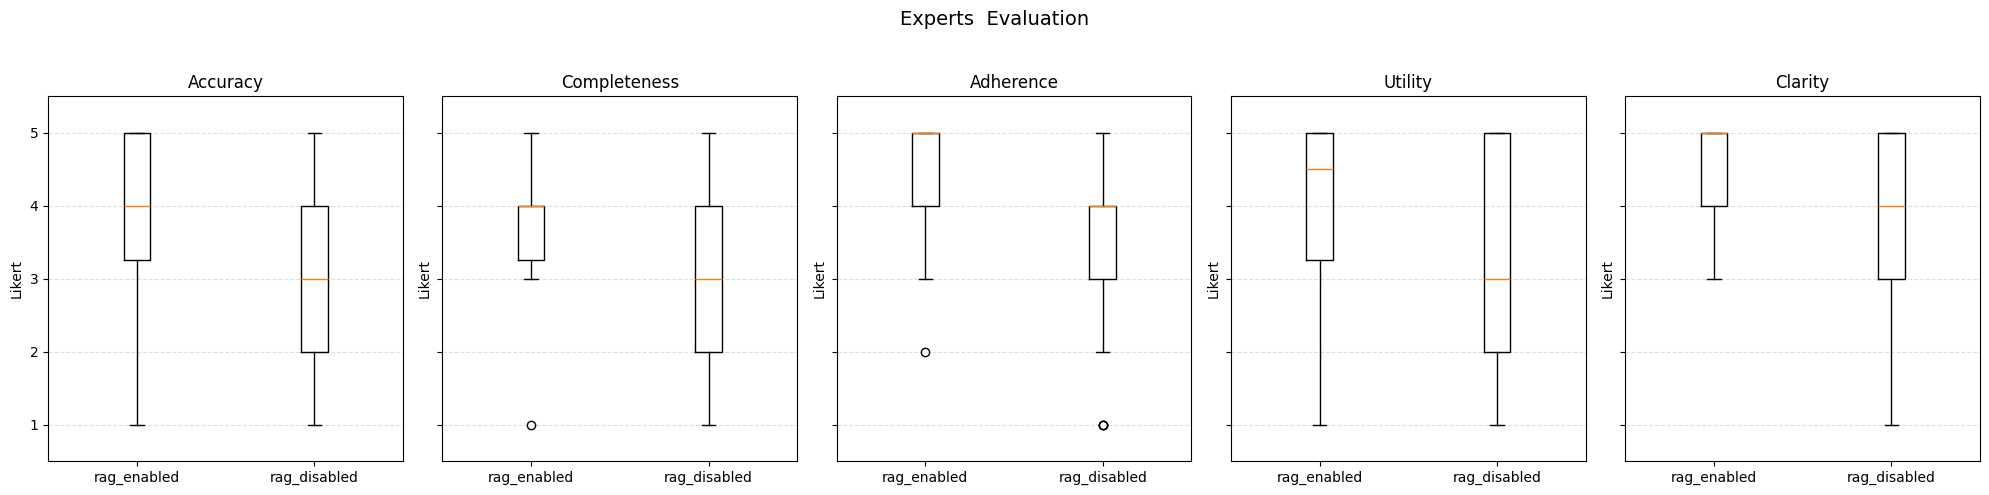

In [40]:
plot_boxplots_todas_dimensoes(
    df=df_analise,
    dict_dimensoes=dict_dim_humanos,
    titulo_geral="Experts  Evaluation",
    label_rag="rag_enabled",
    label_gpt="rag_disabled"
)

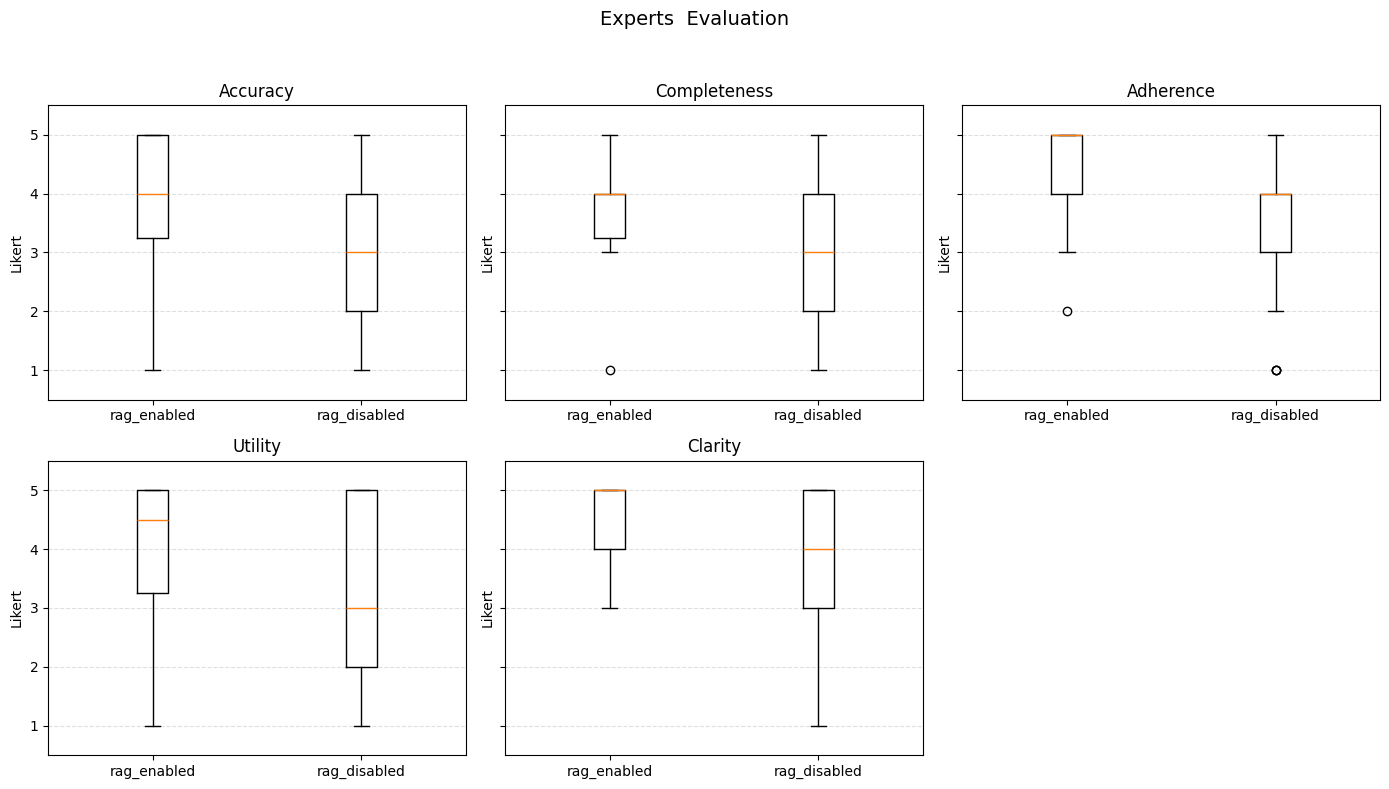

In [41]:
plot_boxplots_todas_dimensoes_grid(
    df=df_analise,
    dict_dimensoes=dict_dim_humanos,
    titulo_geral="Experts  Evaluation"
)

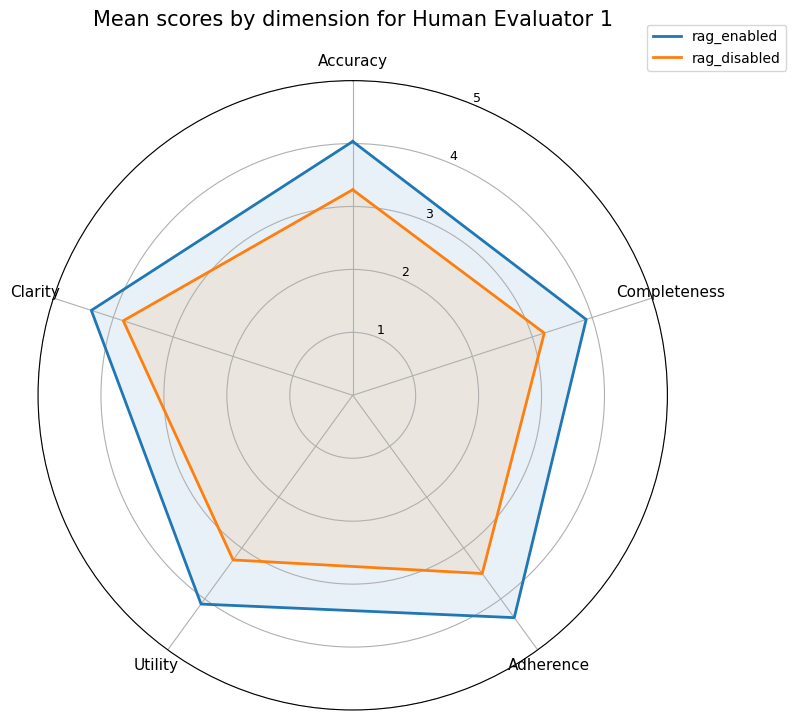

In [ ]:
plot_radar_medias_dimensoes(
    df_estatisticas=df_estat_humanos,
    titulo="Mean scores by dimension for Human Evaluator 1",
    figsize=(8, 8),
    title_fontsize=15,    
    label_rag = "With RAG",
    label_gpt = "Without RAG",
    axis_label_fontsize=11,
    radial_tick_fontsize=9,
    legend_fontsize=10
)

### Comparativo preferência global

In [43]:
df_analise.head(2)

,ID,question,response_A,response_B,A_origin,Accuracy_rag_enabled,Completeness_rag_enabled,Adherence_rag_enabled,Utility_rag_enabled,Clarity_rag_enabled,Accuracy_rag_disabled,Completeness_rag_disabled,Adherence_rag_disabled,Utility_rag_disabled,Clarity_rag_disabled,global_preference_human_judge_origin
0,1,Quais são os principais papéis e responsabilid...,O Decreto 10.046/2019 define que a Secretaria ...,Os principais papéis e responsabilidades defin...,rag_disabled,5,3,5,3,5,1,1,3,1,4,rag_enabled
1,2,"Segundo a LGPD, quais são os princípios fundam...",Os princípios fundamentais para o tratamento d...,A LGPD estabelece que o tratamento de dados pe...,rag_enabled,5,4,5,5,5,5,3,5,5,5,tie


In [44]:
df_analise["global_preference_human_judge_origin"].unique()

array(['rag_enabled', 'tie', 'rag_disabled'], dtype=object)

In [45]:

def analisar_preferencia_global(
    df: pd.DataFrame,
    coluna_preferencia: str = "global_preference_human_judge_origin"
) -> pd.DataFrame:
    """
    Faz uma análise simples da preferência global.
    
    Espera valores como:
    - rag_enabled
    - rag_disabled
    - tie
    """

    if coluna_preferencia not in df.columns:
        raise ValueError(f"A coluna '{coluna_preferencia}' não está no dataframe.")

    serie = (
        df[coluna_preferencia]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    categorias_esperadas = ["rag_enabled", "rag_disabled", "tie"]

    contagens = serie.value_counts(dropna=False)
    total = len(serie)

    resultados = []
    for cat in categorias_esperadas:
        n = int(contagens.get(cat, 0))
        perc = (n / total * 100) if total > 0 else 0.0
        resultados.append({
            "category": cat,
            "n": n,
            "percentage": perc
        })

    df_resultado = pd.DataFrame(resultados)

    # métricas extras
    n_rag = int(contagens.get("rag_enabled", 0))
    n_gpt = int(contagens.get("rag_disabled", 0))
    n_empate = int(contagens.get("tie", 0))
    n_decididos = n_rag + n_gpt

    taxa_vitoria_rag = (n_rag / n_decididos * 100) if n_decididos > 0 else None
    taxa_vitoria_gpt = (n_gpt / n_decididos * 100) if n_decididos > 0 else None

    resumo = pd.DataFrame([
        {
            "total_observations": total,
            "n_decided_without_empate": n_decididos,
            "n_tie": n_empate,
            "win_rate_rag_enabled_without_tie": taxa_vitoria_rag,
            "win_rate_rag_disabled_without_tie": taxa_vitoria_gpt
        }
    ])

    return df_resultado, resumo

In [ ]:
def plot_preferencia_global(
    df: pd.DataFrame,
    coluna_preferencia: str = "global_preference_human_judge_origin",
    titulo: str = "Global preference of Human Evaluator 1",
    categorias: list = ["rag_enabled", "rag_disabled", "tie"],
    fontsize_titulo: int = 12,
    fontsize_eixos: int = 10,
    fontsize_valores: int = 10
):
    serie = (
        df[coluna_preferencia]
        .astype(str)
        .str.strip()
    )
    
    contagens = [int((serie == cat).sum()) for cat in categorias]

    fig, ax = plt.subplots(figsize=(6, 4))
    barras = ax.bar(categorias, contagens)

    ax.set_title(titulo, fontsize=fontsize_titulo)
    ax.set_ylabel("Frequency", fontsize=fontsize_eixos)
    ax.set_xlabel("Category", fontsize=fontsize_eixos)
    ax.set_ylim(0, 25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # adiciona os valores acima das barras
    for barra, valor in zip(barras, contagens):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.1,
            str(valor),
            ha="center",
            va="bottom",
            fontsize=fontsize_valores
        )

    plt.tight_layout()
    plt.show()

In [47]:
df_pref_global, df_pref_global_resumo = analisar_preferencia_global(
    df=df_analise,
    coluna_preferencia="global_preference_human_judge_origin"
)


In [48]:
df_pref_global

,category,n,percentage
0,rag_enabled,14,46.666667
1,rag_disabled,6,20.000000
2,tie,10,33.333333


In [49]:
df_pref_global_resumo

,total_observations,n_decided_without_empate,n_tie,win_rate_rag_enabled_without_tie,win_rate_rag_disabled_without_tie
0,30,20,10,70.0,30.0


In [ ]:
# aplica uma mudanca na coluna
df_analise.head(2)

In [ ]:
df_grafico = df_analise.copy()

# na coluna "global_preference_human_judge_origin", vamos trocar "rag_enabled" por "With RAG", "rag_disabled" por "Without RAG" e "tie" por "Tie"
df_grafico["global_preference_human_judge_origin"] = df_grafico["global_preference_human_judge_origin"].replace({
    "rag_enabled": "With RAG",
    "rag_disabled": "Without RAG",
    "tie": "Tie"
})
df_grafico["global_preference_human_judge_origin"].value_counts()

In [ ]:
plot_preferencia_global(df = df_grafico,
                        coluna_preferencia="global_preference_human_judge_origin",
                        titulo="Global Preference of the Human Evaluator 2",
                        categorias=["With RAG", "Without RAG", "Tie"])